# DATA PREPARATION


## SET UP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sqlalchemy as sa


%config IPCompleter.greedy=True

pd.options.display.max_columns = None

## DATA LOAD

In [2]:
con = sa.create_engine('sqlite:///data/airbnb.db')

df = pd.read_sql('df', con = con)

df.head()

,index,id,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365,description,host_is_superhost,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating,review_scores_communication,review_scores_location,precio_m2,distrito
0,0,6369,"Rooftop terrace room , ensuite bathroom",13660,Chamartín,Hispanoamérica,40.45724,-3.67688,Private room,60,1,2,180,Excellent connection with the AIRPORT and EXHI...,t,2,1.0,1.0,80,4.87,4.89,4.77,5098,Chamartín
1,1,21853,Bright and airy room,83531,Latina,Cármenes,40.40381,-3.74130,Private room,31,4,2,364,We have a quiet and sunny room with a good vie...,f,1,1.0,1.0,33,4.58,4.82,4.21,2267,Latina
2,2,23001,Apartmento Arganzuela- Madrid Rio,82175,Arganzuela,Legazpi,40.38840,-3.69511,Entire home/apt,50,15,5,222,"Apartamento de tres dormitorios dobles, gran s...",f,6,3.0,5.0,0,NaN,NaN,NaN,4085,Arganzuela
3,3,24805,Gran Via Studio Madrid,346366726,Centro,Universidad,40.42183,-3.70529,Entire home/apt,92,5,1,115,"Studio located 50 meters from Gran Via, next t...",f,3,1.0,1.0,12,4.92,5.00,5.00,4827,Centro
4,4,26825,Single Room whith private Bathroom,114340,Arganzuela,Legazpi,40.38975,-3.69018,Private room,26,2,1,349,Nice and cozy roon for one person with a priva...,f,1,1.0,1.0,149,4.68,4.71,4.70,4085,Arganzuela


## VARIABLE PREPARATION

### Lever kpi creation


First lets create the analysis variables, the ones we've identified:

* price per night: we already have this directly in the price variable, but we are going to review it to see that we understand it well
* occupancy: we have availability_365 but we have to transform it
* property price: we will have to create this with external variables so we leave it for later

**PRICE.**

Documentation doesn't make clear if the price is by property or by room

Is a key information to evaluate the potential value. We can try to understand it analyzing the price mean by type of rental.

Important to filter only by district to no include a "zone" effect

So, first choose district with lots of data

In [3]:
df.distrito.value_counts()

distrito
Centro                   8127
Salamanca                1218
Chamberí                 1089
Arganzuela               1005
Tetuán                    762
Retiro                    618
Carabanchel               581
Chamartín                 538
Ciudad Lineal             532
Moncloa - Aravaca         493
Puente de Vallecas        465
San Blas - Canillejas     463
Latina                    455
Hortaleza                 354
Fuencarral - El Pardo     265
Usera                     233
Barajas                   142
Villaverde                129
Moratalaz                  94
Villa de Vallecas          90
Vicálvaro                  57
Name: count, dtype: int64

In [4]:
df.loc[df.distrito == 'Centro',:].groupby('room_type').price.mean()

room_type
Entire home/apt    148.859980
Private room        67.131643
Shared room         60.464286
Name: price, dtype: float64

    
* renting an apartment has an average price of €148
* renting a room has an average price of €60 or €67 depending on whether it is shared or private
* therefore, to calculate the "income" of a property we must multiply the price by the number of rooms when it is a Private room or Shared room type

Now, multiplying the price by the total number of rooms can artificially skew the income-generating capacity of a property upwards, because if it is rented by room it is not likely to always be at 100%.

Therefore we should weight it by the average percentage of rooms rented. We don't have that data, but let's assume that it is 70%.

We can create the total price variable by applying apply to a custom function.

In [5]:
def crear_precio_total(registro):
    if (registro.beds > 1) & ((registro.room_type == 'Private room') | (registro.room_type == 'Shared room')):
        salida = registro.price * registro.beds * 0.7
    else:
        salida = registro.price
    return(salida)

df['precio_total'] = df.apply(crear_precio_total, axis = 1)

In [6]:
df[['room_type','price','beds','precio_total']].head(30)

,room_type,price,beds,precio_total
0,Private room,60,1.0,60.0
1,Private room,31,1.0,31.0
2,Entire home/apt,50,5.0,50.0
3,Entire home/apt,92,1.0,92.0
4,Private room,26,1.0,26.0
5,Entire home/apt,85,3.0,85.0
6,Entire home/apt,65,2.0,65.0
7,Entire home/apt,54,1.0,54.0
8,Entire home/apt,1400,3.0,1400.0
9,Entire home/apt,81,2.0,81.0


**OCCUPANCY**

Using availability_365, this variable tells the number of days NOT occupied in a year

We would therefore be interested in transforming it into a more direct measure of occupancy, for example the % of the year that it IS occupied.

We can do this with a direct transformation.

In [7]:
df['ocupacion'] = ((365 - df.availability_365) / 365 * 100).astype('int')
df.head()

,index,id,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365,description,host_is_superhost,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating,review_scores_communication,review_scores_location,precio_m2,distrito,precio_total,ocupacion
0,0,6369,"Rooftop terrace room , ensuite bathroom",13660,Chamartín,Hispanoamérica,40.45724,-3.67688,Private room,60,1,2,180,Excellent connection with the AIRPORT and EXHI...,t,2,1.0,1.0,80,4.87,4.89,4.77,5098,Chamartín,60.0,50
1,1,21853,Bright and airy room,83531,Latina,Cármenes,40.40381,-3.74130,Private room,31,4,2,364,We have a quiet and sunny room with a good vie...,f,1,1.0,1.0,33,4.58,4.82,4.21,2267,Latina,31.0,0
2,2,23001,Apartmento Arganzuela- Madrid Rio,82175,Arganzuela,Legazpi,40.38840,-3.69511,Entire home/apt,50,15,5,222,"Apartamento de tres dormitorios dobles, gran s...",f,6,3.0,5.0,0,NaN,NaN,NaN,4085,Arganzuela,50.0,39
3,3,24805,Gran Via Studio Madrid,346366726,Centro,Universidad,40.42183,-3.70529,Entire home/apt,92,5,1,115,"Studio located 50 meters from Gran Via, next t...",f,3,1.0,1.0,12,4.92,5.00,5.00,4827,Centro,92.0,68
4,4,26825,Single Room whith private Bathroom,114340,Arganzuela,Legazpi,40.38975,-3.69018,Private room,26,2,1,349,Nice and cozy roon for one person with a priva...,f,1,1.0,1.0,149,4.68,4.71,4.70,4085,Arganzuela,26.0,4


### Analysis variables transformation

Some of the seed questions are aimed at checking how the price or occupancy behaves according to other variables such as the number of rooms, the average number of reviews, etc.

Normally we can do these analyses better if we discretize the analysis variable.

In our case the candidates for this analysis are: accommodates, bedrooms, beds and number_of_reviews.

In bedrooms a more personalized discretization makes sense. In the others we can be done automatically.

**Discretize bedrooms**

let's check the distribution

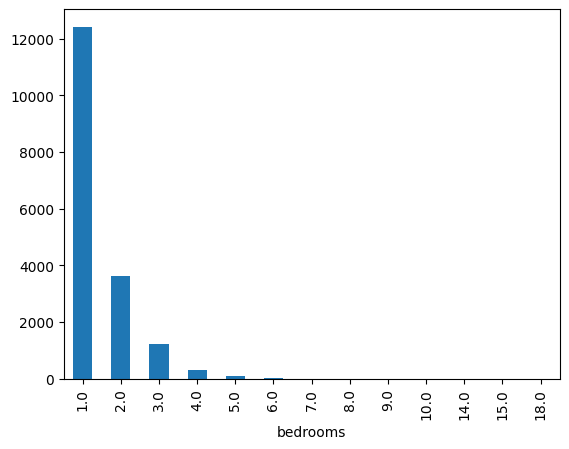

In [8]:
df.bedrooms.value_counts().plot.bar();

discretize for 1,2,3 and more than 3.

using np.select

In [9]:
condiciones = [df.bedrooms == 1,
               df.bedrooms == 2,
               df.bedrooms == 3,
               df.bedrooms > 3]

resultados = ['01_Una','02_Dos','03_Tres','04_Cuatro o mas']

df['bedrooms_disc'] = np.select(condiciones, resultados, default = -999)

Check

In [10]:
df.bedrooms_disc.value_counts()

bedrooms_disc
01_Una             12422
02_Dos              3617
03_Tres             1228
04_Cuatro o mas      443
Name: count, dtype: int64

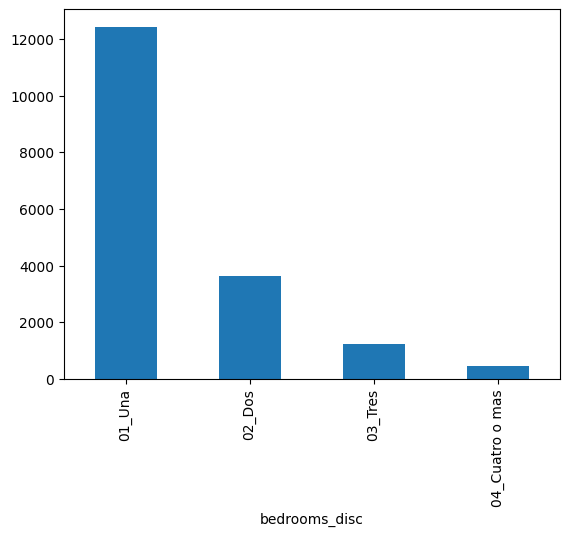

In [11]:
df.bedrooms_disc.value_counts().plot.bar();

**Discretize accommodates, beds and number_of_reviews**

percentiles 0.5, 0.8, 1

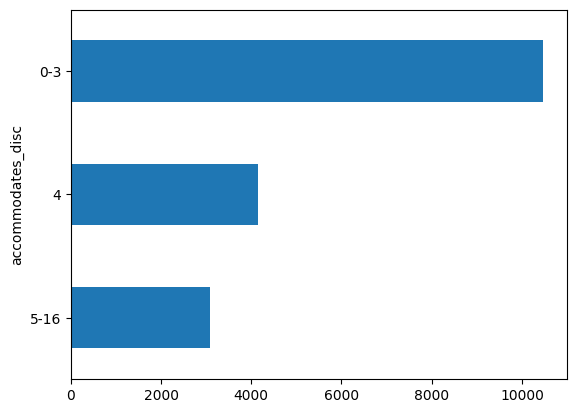

In [12]:
df['accommodates_disc'] = pd.qcut(df.accommodates,[0, 0.5, 0.8, 1],
                                 labels = ['0-3','4','5-16'])

df['accommodates_disc'].value_counts().sort_index(ascending = False).plot.barh();

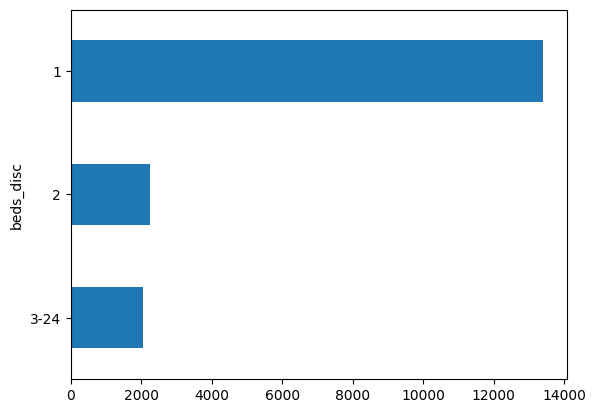

In [13]:
df['beds_disc'] = pd.qcut(df.beds,[0, 0.5, 0.8, 1],
                         labels = ['1','2','3-24'])

df['beds_disc'].value_counts().sort_index(ascending = False).plot.barh();

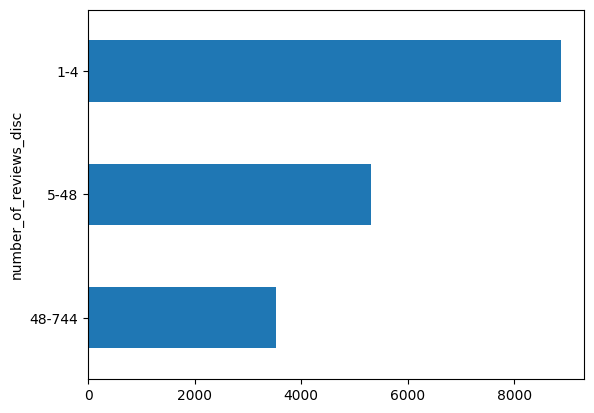

In [14]:
df['number_of_reviews_disc'] = pd.qcut(df.number_of_reviews,[0, 0.5, 0.8, 1],
                                      labels = ['1-4','5-48','48-744'])

df['number_of_reviews_disc'].value_counts().sort_index(ascending = False).plot.barh();

### Variable creation with the external data

In this case we could make lots of things with external data. 

First, already partially incorporated, the lever of the price. We can estimate it multiplying the m2 of the property by the price by m2, which we adquired. We need the size of the property, though.

We can estimate it based on the number of rooms, isn't perfect but it will work as an approximation.


**Estimating the square meters of the property**

We will use the following algorithm:

* one room: m2 = 50
* two rooms: m2 = 70
* three rooms: m2 = 90
* four rooms: m2 = 120
* five or more rooms: m2 = 150

In [15]:
condiciones = [df.bedrooms == 1,
               df.bedrooms == 2,
               df.bedrooms == 3,
               df.bedrooms == 4,
               df.bedrooms > 4]

resultados = [50,70,90,120,150]

df['m2'] = np.select(condiciones, resultados, default = -999)

In [16]:
df['m2'].value_counts()

m2
50     12422
70      3617
90      1228
120      296
150      147
Name: count, dtype: int64

Now we can estimate the purchase price of the property.

We remember that we subtracted 30% from the price we got for negotiating power.

In [17]:
df['precio_compra'] = df.m2 * df.precio_m2 * 0.7

In [18]:
df[['bedrooms','m2','distrito','precio_m2','precio_compra']].head(20)

,bedrooms,m2,distrito,precio_m2,precio_compra
0,1.0,50,Chamartín,5098,178430.0
1,1.0,50,Latina,2267,79345.0
2,3.0,90,Arganzuela,4085,257355.0
3,1.0,50,Centro,4827,168945.0
4,1.0,50,Arganzuela,4085,142975.0
5,3.0,90,Arganzuela,4085,257355.0
6,1.0,50,Centro,4827,168945.0
7,1.0,50,Centro,4827,168945.0
8,2.0,70,Centro,4827,236523.0
9,1.0,50,Centro,4827,168945.0



now, let's focus on the coordinates data. We can do lots of things with this information, like calculating distances to different interest points around the city.

As an example, we're going to calculate the distance to la Puerta del Sol for each property.

Location: https://www.123coordenadas.com/coordinates/81497-puerta-del-sol-madrid

Latitude: 40.4167278
Longitude: -3.7033387

**Calculating the distance of each property to la Puerta del Sol**

I'm going to take into account the earth's curvature, but for this distances isn't really noticeable.

https://stackoverflow.com/questions/4913349/haversine-formula-in-python-bearing-and-distance-between-two-gps-points

In [19]:
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):

      R = 6372.8 #km

      dLat = radians(lat2 - lat1)
      dLon = radians(lon2 - lon1)
      lat1 = radians(lat1)
      lat2 = radians(lat2)

      a = sin(dLat/2)**2 + cos(lat1)*cos(lat2)*sin(dLon/2)**2
      c = 2*asin(sqrt(a))

      return R * c

In [20]:
#Las coordenadas de la Puerta del Sol serán lat1 y lon1
lat1 = 40.4167278
lon1 = -3.7033387

df['pdi_sol'] = df.apply(lambda registro: haversine(lat1,lon1,registro.latitude,registro.longitude),axis = 1)

In [21]:
df.groupby('distrito').pdi_sol.mean().sort_values()

distrito
Centro                    0.730611
Arganzuela                1.939114
Chamberí                  2.133167
Retiro                    2.450593
Salamanca                 2.715975
Moncloa - Aravaca         3.294526
Usera                     3.928874
Latina                    3.942634
Carabanchel               3.970238
Chamartín                 4.432842
Puente de Vallecas        4.481127
Tetuán                    4.624605
Moratalaz                 5.073901
Ciudad Lineal             5.231293
Villaverde                7.664192
Fuencarral - El Pardo     8.062301
Hortaleza                 8.074184
San Blas - Canillejas     8.199011
Vicálvaro                 8.599559
Villa de Vallecas         9.176618
Barajas                  11.439064
Name: pdi_sol, dtype: float64

## SAVING IN THE DATAMART

In [22]:
df.to_sql('df_preparado', con = con, if_exists = 'replace')

17710